# Week-4


Processing: SF1M2


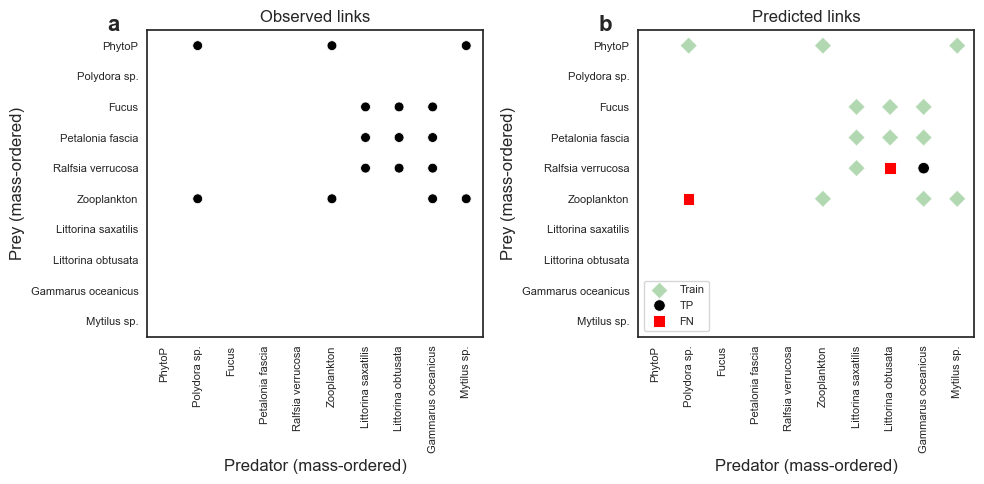


Processing: PP1I3


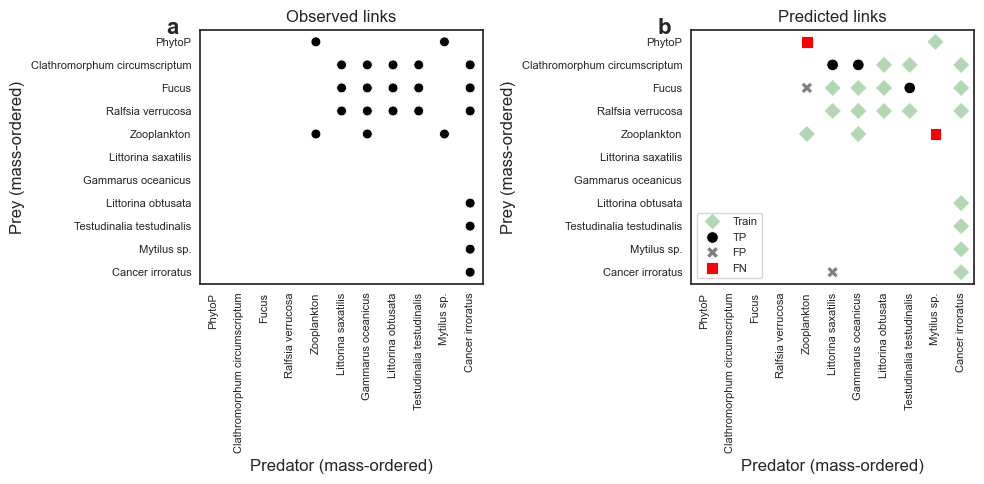


Processing: SP1


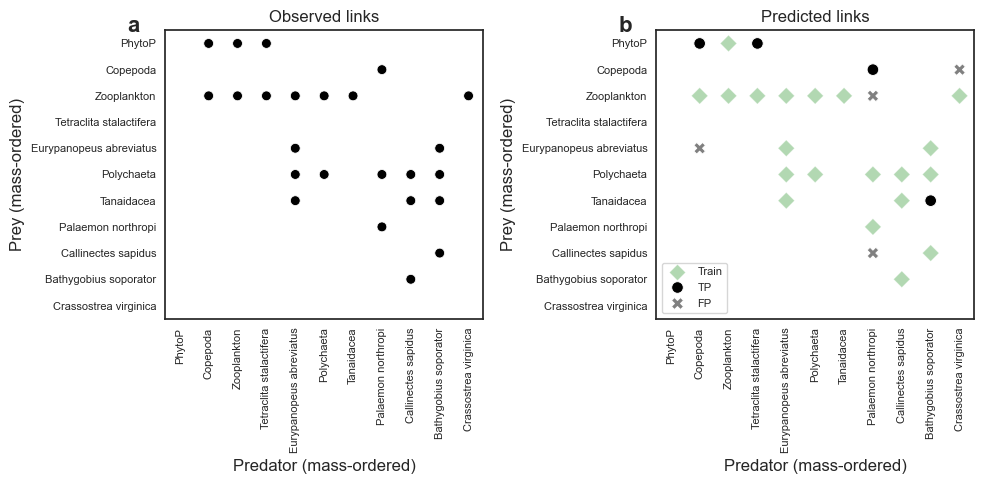


Processing: PC2P5


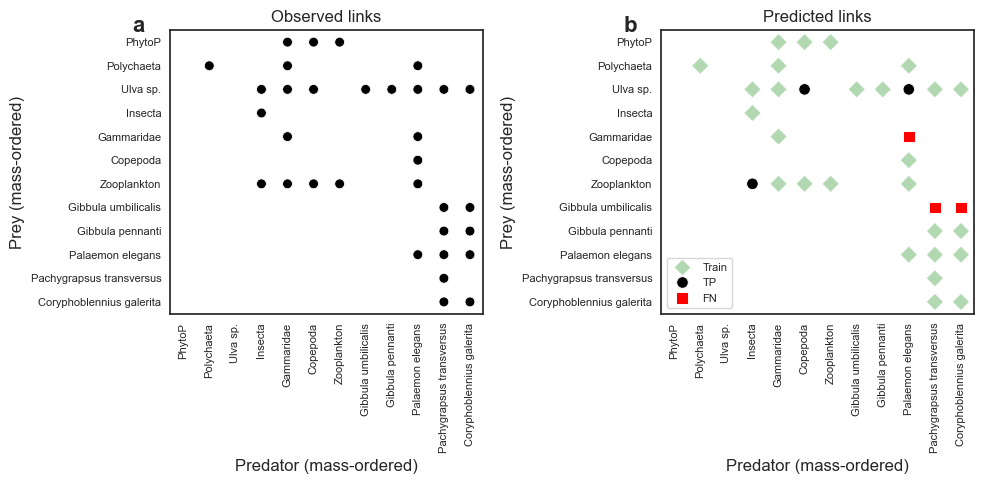


Processing: SF1M1


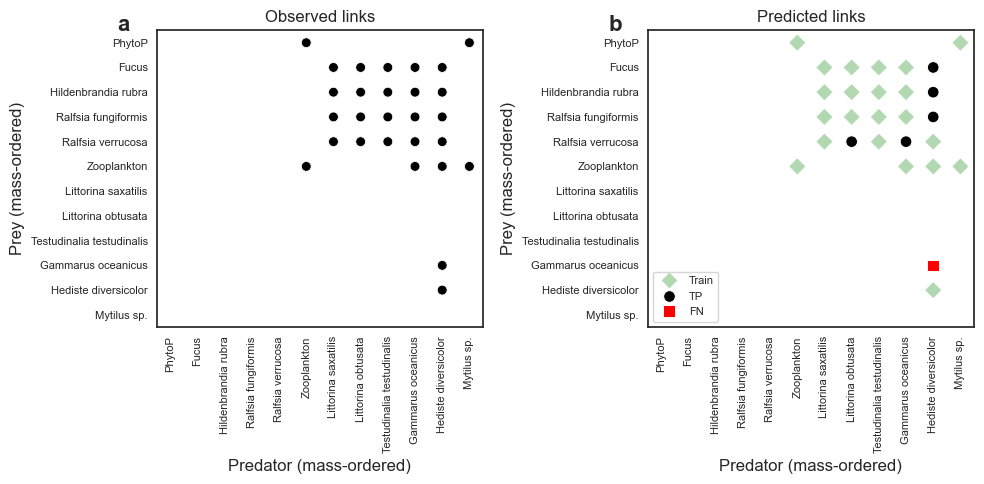

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.io
from scipy.sparse import coo_matrix, csr_matrix
import os

# Apply seaborn style
sns.set_theme(style="white", font_scale=1.0)

# =========================
# Figure controls (flags)
# =========================
MAX_PLOTS = 5

SHOW_TITLES = True          # toggle subplot titles on/off
SHOW_TICKS = True           # toggle tick labels + tick marks on/off

# Paper-friendly labels (only used if SHOW_TITLES=True)
TITLE_LEFT = "Observed links"
TITLE_RIGHT = "Predicted links"

# Paper-friendly axis labels (optional: keep short)
XLAB = "Predator (mass-ordered)"
YLAB = "Prey (mass-ordered)"

# === Load foodweb names list ===
foodwebs_list_df = pd.read_csv("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")

# === Base paths ===
base_csv_path = "../../../src/matlab/data/result_stable_version_290/confusion_matrix_csv"
base_mat_path = "../../../src/matlab/data/foodwebs_mat"

plots_done = 0

# === Iterate over each foodweb ===
for foodweb in foodwebs_list_df["Foodweb"]:
    if plots_done >= MAX_PLOTS:
        break

    print(f"\nProcessing: {foodweb.split('_')[0]}")

    try:
        # === Load CSV prediction results ===
        tp_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio80_TP_links.csv")
        fp_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio80_FP_links.csv")
        fn_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio80_FN_links.csv")
        train_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio80_train_links.csv")
        mat_file = os.path.join(base_mat_path, f"{foodweb}.mat")

        tp = pd.read_csv(tp_file).dropna(subset=['Prey', 'Predator'])
        fp = pd.read_csv(fp_file).dropna(subset=['Prey', 'Predator'])
        fn = pd.read_csv(fn_file).dropna(subset=['Prey', 'Predator'])

        # === Load .mat adjacency and metadata ===
        mat_data = scipy.io.loadmat(mat_file)
        net = mat_data['net']
        taxonomy = [str(t[0]) if isinstance(t, (list, np.ndarray)) else str(t) for t in mat_data['taxonomy'].flatten()]
        mass = mat_data['mass'].flatten()

        # === Sort species by mass ===
        taxonomy_df = pd.DataFrame({'Species': taxonomy, 'Mass': mass})
        taxonomy_df = taxonomy_df.dropna().sort_values(by='Mass').reset_index(drop=True)
        sorted_species = taxonomy_df['Species'].tolist()
        species_index = {name: i for i, name in enumerate(sorted_species)}
        N = len(sorted_species)
        sorted_species_reversed = sorted_species[::-1]

        # === Sort adjacency matrix by mass ===
        if isinstance(net, coo_matrix):
            net = net.tocsr()
        elif isinstance(net, (np.ndarray, list)):
            net = csr_matrix(net)
        idx_sorted = [taxonomy.index(sp) for sp in sorted_species]
        adj_sorted = net[np.ix_(idx_sorted, idx_sorted)].toarray().astype(float)

        # === Build DataFrame for Adjacency Matrix (non-zero links) ===
        am_rows, am_cols = np.where(adj_sorted == 1)
        df_am = pd.DataFrame({
            'PreyIdx': N - 1 - am_rows,  # flip y-axis
            'PredIdx': am_cols,
            'Label': 'Link'
        })

        # === Filter predictions to valid species ===
        tp = tp[tp['Prey'].isin(species_index) & tp['Predator'].isin(species_index)]
        fp = fp[fp['Prey'].isin(species_index) & fp['Predator'].isin(species_index)]
        fn = fn[fn['Prey'].isin(species_index) & fn['Predator'].isin(species_index)]

        # === Build DataFrame for Predation Matrix
        def make_df(df, label):
            return pd.DataFrame({
                'PreyIdx': df['Prey'].map(species_index),
                'PredIdx': df['Predator'].map(species_index),
                'Label': label
            })

        df_pm = pd.concat([
            make_df(tp, 'TP'),
            make_df(fp, 'FP'),
            make_df(fn, 'FN')
        ]).dropna().astype({'PreyIdx': int, 'PredIdx': int})
        df_pm['PreyIdx'] = N - 1 - df_pm['PreyIdx']

        # === Load Training Links (if available)
        df_train = None
        if os.path.isfile(train_file):
            train = pd.read_csv(train_file).dropna(subset=['Prey', 'Predator'])
            train = train[train['Prey'].isin(species_index) & train['Predator'].isin(species_index)]
            df_train = pd.DataFrame({
                'PreyIdx': train['Prey'].map(species_index),
                'PredIdx': train['Predator'].map(species_index),
                'Label': 'Train'
            })
            df_train['PreyIdx'] = N - 1 - df_train['PreyIdx']

        # === Plotting
        fig, axs = plt.subplots(1, 2, figsize=(10, 5))

        # Panel labels (top-left corner, outside each axis)
        axs[0].text(-0.12, 1.05, "a", transform=axs[0].transAxes,
                    fontsize=16, fontweight="bold", va="top", ha="left", clip_on=False)
        axs[1].text(-0.12, 1.05, "b", transform=axs[1].transAxes,
                    fontsize=16, fontweight="bold", va="top", ha="left", clip_on=False)

        # LEFT: Adjacency Matrix
        sns.scatterplot(
            data=df_am, x='PredIdx', y='PreyIdx', hue='Label', style='Label',
            markers={'Link': 'o'}, palette={'Link': 'black'}, s=50, ax=axs[0]
        )

        # RIGHT: Predation Matrix
        ax = axs[1]

        # Plot training links first (background), with low opacity and include in legend
        if df_train is not None:
            sns.scatterplot(
                data=df_train, x='PredIdx', y='PreyIdx', hue='Label', style='Label',
                markers={'Train': 'D'}, palette={'Train': 'green'},
                alpha=0.3, s=70, legend='brief', ax=ax
            )

        # Plot TP, FP, FN
        sns.scatterplot(
            data=df_pm, x='PredIdx', y='PreyIdx', hue='Label', style='Label',
            markers={'TP': 'o', 'FP': 'X', 'FN': 's', 'Train': 'D'},
            palette={'TP': 'black', 'FP': 'gray', 'FN': 'red', 'Train': 'green'},
            s=70, ax=ax
        )

        ax.legend(loc='lower left', fontsize=8, title="")

        # =========================
        # Professional axes styling
        # =========================
        for a in axs:
            # Keep geometry identical to your original logic
            a.invert_yaxis()
            a.set_xlim(-0.5, N - 0.5)
            a.set_ylim(-0.5, N - 0.5)

            if SHOW_TITLES:
                if a is axs[0]:
                    a.set_title(TITLE_LEFT, fontsize=12)
                else:
                    a.set_title(TITLE_RIGHT, fontsize=12)
            else:
                a.set_title("")

            # Paper-friendly axis labels (or remove entirely if you prefer)
            a.set_xlabel(XLAB)
            a.set_ylabel(YLAB)

            # Ticks toggle
            if SHOW_TICKS:
                a.set_xticks(range(N))
                a.set_yticks(range(N))
                a.set_xticklabels(sorted_species, rotation=90, fontsize=8)
                a.set_yticklabels(sorted_species_reversed, fontsize=8)
                a.tick_params(axis='both', which='both', length=3)
            else:
                a.set_xticks([])
                a.set_yticks([])
                a.set_xticklabels([])
                a.set_yticklabels([])
                a.tick_params(axis='both', which='both', length=0)

        # Remove legend on left panel (as you had)
        axs[0].legend([], [], frameon=False)

        plt.tight_layout()
        plt.show()

        plots_done += 1

    except Exception as e:
        print(f"Skipping {foodweb} due to error: {e}")

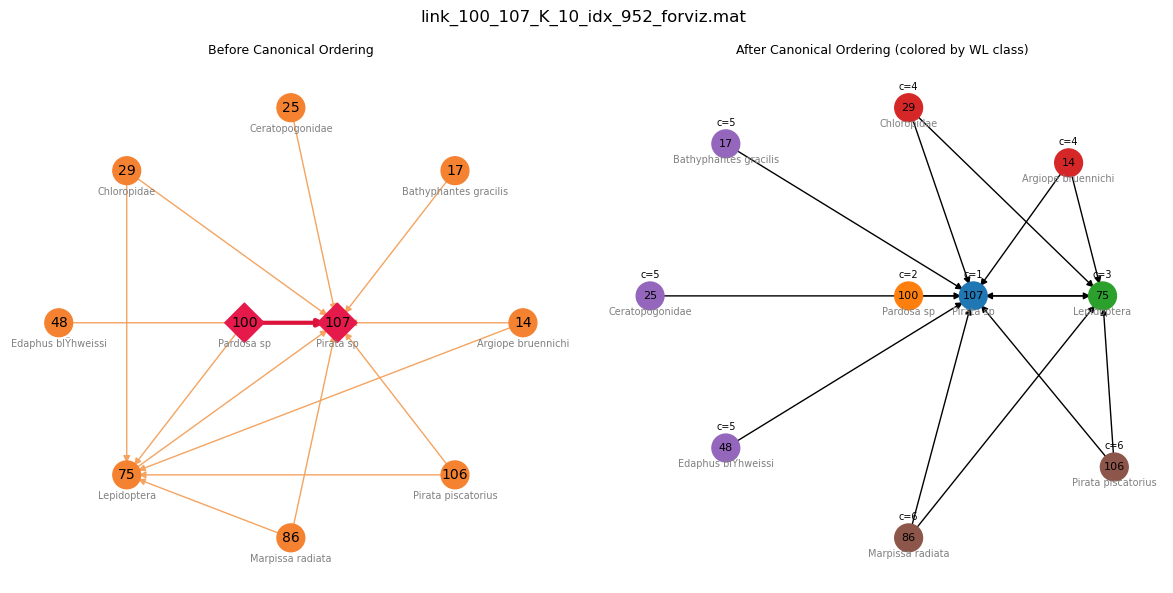

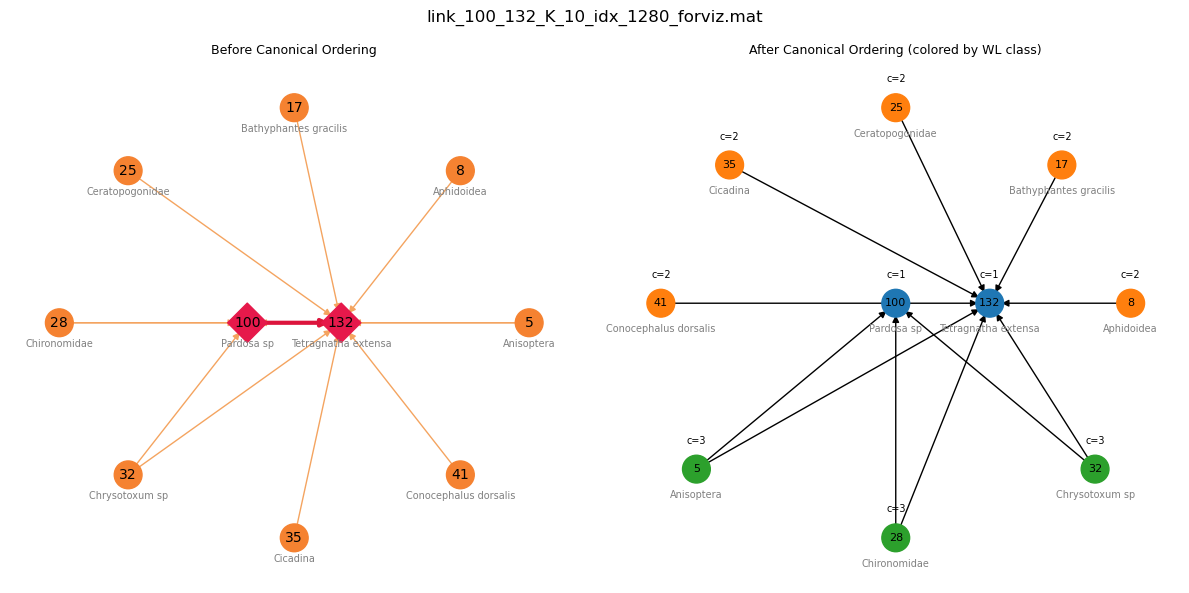

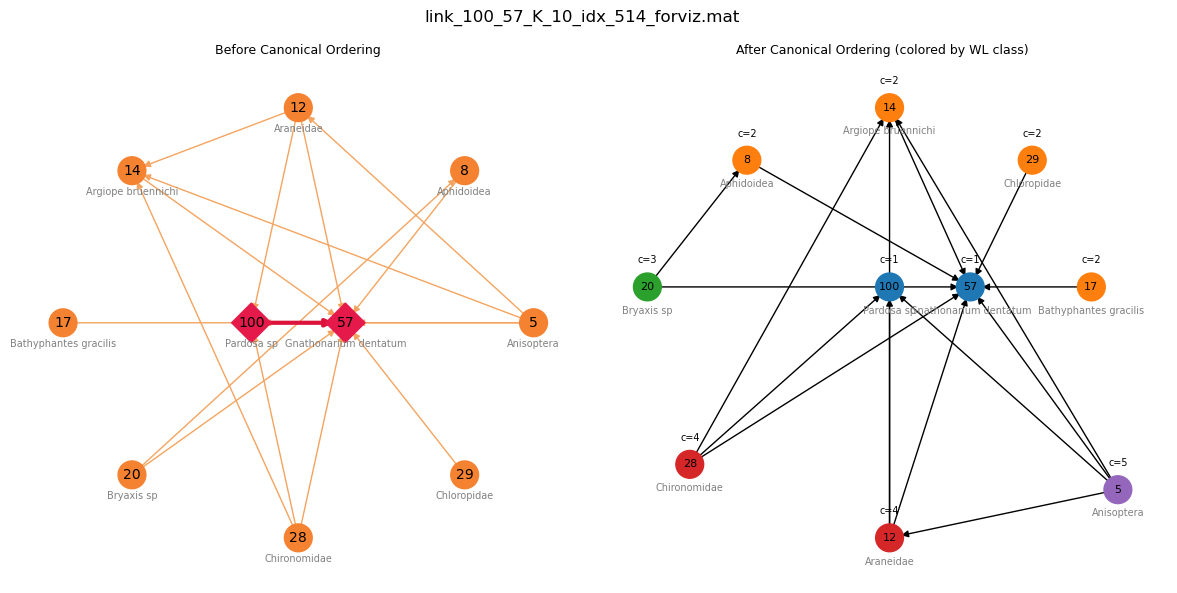

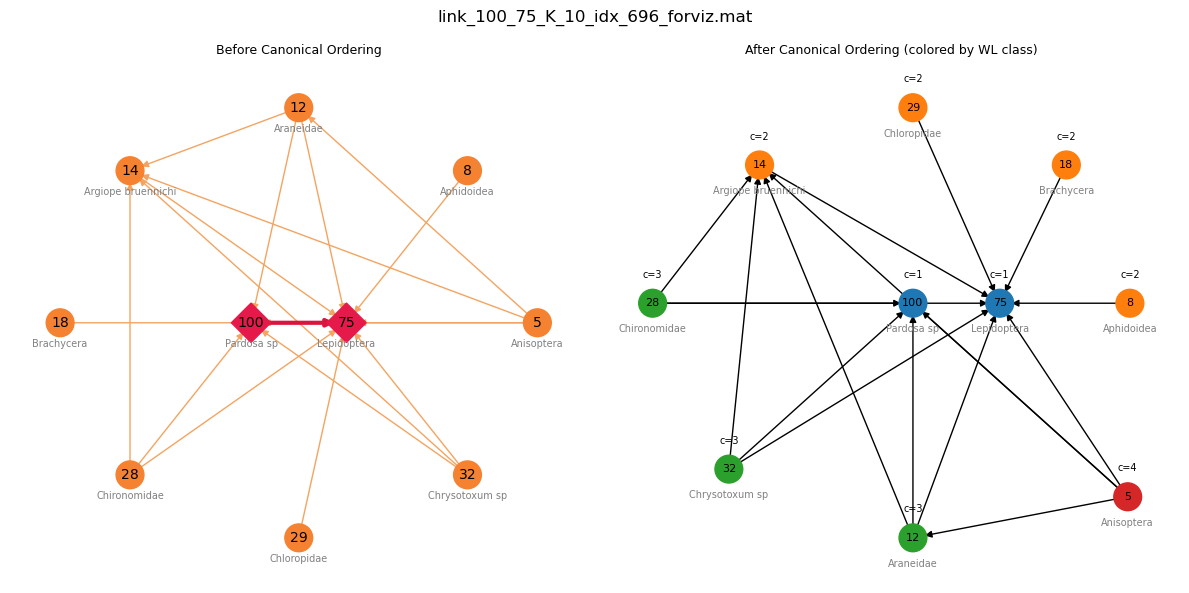

In [4]:
import os
import scipy.io
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import math

# Función de colores por clase WL
def get_node_colors_by_classes(classes):
    unique_classes = np.unique(classes)
    cmap = plt.get_cmap("tab10") if len(unique_classes) <= 10 else plt.get_cmap("tab20")
    color_map = {cls: cmap(i % cmap.N) for i, cls in enumerate(unique_classes)}
    return [color_map[c] for c in classes]

# Layout centrado para G1
def centered_layout(G, link, radius=2.5):
    source, target = link
    pos = {
        source: np.array([-0.5, 0.0]),
        target: np.array([0.5, 0.0])
    }
    remaining = [n for n in G.nodes() if n not in link]
    n = len(remaining)
    if n == 0:
        return pos
    angles = np.linspace(0, 2 * math.pi, n, endpoint=False)
    for i, node in enumerate(remaining):
        pos[node] = np.array([radius * math.cos(angles[i]), radius * math.sin(angles[i])])
    return pos

# Función principal de visualización
def visualize_subgraph_pair(mat_block_path, mat_full_path):
    mat_block = scipy.io.loadmat(mat_block_path)
    required_keys = ['adj_before', 'adj_after', 'nodes', 'nodes_ordered', 'classes', 'link', 'label']
    if not all(k in mat_block for k in required_keys):
        print(f"⚠️ Skipping incomplete: {os.path.basename(mat_block_path)}")
        return

    label = int(mat_block["label"].flatten()[0])
    if ONLY_POSITIVES and label == 0:
        return

    A_before = mat_block["adj_before"]
    A_after = mat_block["adj_after"]
    nodes = mat_block["nodes"].flatten()
    nodes_ordered = mat_block["nodes_ordered"].flatten()
    classes = mat_block["classes"].flatten()
    link = mat_block["link"].flatten()
    pred, prey = map(int, link)

    # Cargar metadata del food web completo
    if not os.path.exists(mat_full_path):
        print(f"⛔️ Foodweb file missing: {mat_full_path}")
        return
    mat_full = scipy.io.loadmat(mat_full_path)
    taxonomy_raw = mat_full.get("taxonomy")
    if taxonomy_raw is None:
        print(f"⛔️ 'taxonomy' missing in {mat_full_path}")
        return
    taxonomy = [str(t[0]) for t in taxonomy_raw[0]]

    G1 = nx.from_numpy_array(A_before, create_using=nx.DiGraph)
    G2 = nx.from_numpy_array(A_after, create_using=nx.DiGraph)
    mapping_before = {i: int(nodes[i]) for i in range(len(nodes))}
    mapping_after = {i: int(nodes_ordered[i]) for i in range(len(nodes_ordered))}
    G1 = nx.relabel_nodes(G1, mapping_before)
    G2 = nx.relabel_nodes(G2, mapping_after)

    # Omitir subgrafos donde el link no existe
    if not G1.has_edge(pred, prey):
        # print(f"⏭️  Skipping: link ({pred} → {prey}) not in G1 for {os.path.basename(mat_block_path)}")
        return

    highlighted_nodes = {pred, prey}
    node_colors_G1 = ['#e6194b' if n in highlighted_nodes else '#f58231' for n in G1.nodes()]
    node_shapes_G1 = ['D' if n in highlighted_nodes else 'o' for n in G1.nodes()]
    colors_G2 = get_node_colors_by_classes(classes)

    pos1 = centered_layout(G1, link)
    center_pred = (0.0, 0.0)
    center_prey = (1.0, 0.0)
    radius_base = 1.5
    pos2 = {pred: center_pred, prey: center_prey}
    rest_nodes = [n for i, n in enumerate(G2.nodes()) if n not in (pred, prey)]
    rest_classes = [classes[i] for i, n in enumerate(G2.nodes()) if n not in (pred, prey)]
    angle_step = 2 * math.pi / len(rest_nodes) if rest_nodes else 0

    for i, node in enumerate(rest_nodes):
        c = rest_classes[i]
        radius = radius_base + 0.5 * c
        angle = i * angle_step
        x = radius * math.cos(angle)
        y = radius * math.sin(angle)
        pos2[node] = (x, y)

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    for shape in set(node_shapes_G1):
        nodelist = [n for n, s in zip(G1.nodes(), node_shapes_G1) if s == shape]
        colorlist = [node_colors_G1[list(G1.nodes()).index(n)] for n in nodelist]
        nx.draw_networkx_nodes(G1, pos1, nodelist=nodelist, node_color=colorlist,
                               node_shape=shape, node_size=400, ax=axs[0])

    normal_edges_G1 = [e for e in G1.edges() if e != (pred, prey)]
    nx.draw_networkx_edges(G1, pos1, edgelist=normal_edges_G1, edge_color='sandybrown', arrows=True, ax=axs[0])
    if G1.has_edge(pred, prey):
        nx.draw_networkx_edges(G1, pos1, edgelist=[(pred, prey)], edge_color='crimson', width=3, arrows=True, ax=axs[0])

    nx.draw_networkx_labels(G1, pos1, ax=axs[0], font_size=10)
    for node in G1.nodes():
        x, y = pos1[node]
        name = taxonomy[node] if 0 <= node < len(taxonomy) else str(node)
        axs[0].text(x, y - 0.3, name, fontsize=7, ha='center', va='bottom', color='grey')

    axs[0].set_title("Before Canonical Ordering", fontsize=9)
    axs[0].axis("off")

    nx.draw_networkx_nodes(G2, pos2, ax=axs[1], node_color=colors_G2, node_size=400)
    nx.draw_networkx_edges(G2, pos2, ax=axs[1], arrows=True)
    nx.draw_networkx_labels(G2, pos2, ax=axs[1], font_size=8)
    for i, node in enumerate(G2.nodes()):
        x, y = pos2[node]
        name = taxonomy[node] if 0 <= node < len(taxonomy) else str(node)
        axs[1].text(x, y + 0.3, f"c={classes[i]}", fontsize=7, ha='center', va='bottom', color='black')
        axs[1].text(x, y - 0.4, name, fontsize=7, ha='center', va='bottom', color='grey')

    axs[1].set_title("After Canonical Ordering (colored by WL class)", fontsize=9)
    axs[1].axis("off")
    fig.suptitle(os.path.basename(mat_block_path), fontsize=12)
    plt.tight_layout()
    plt.show()

# Configuración
ONLY_POSITIVES = True
LIMIT = 5  # Limitar la cantidad de visualizaciones
foodweb_name = "Grand Caricaie  marsh dominated by Cladietum marisci, mown  Clmown1_tax_mass"
building_blocks_dir = f"../../../src/matlab/data/result_building_blocks/building_blocks/{foodweb_name}"
mat_full_path = f"../../../src/matlab/data/foodwebs_mat/{foodweb_name}.mat"

# Ejecutar visualización para archivos limitados
mat_files = sorted([os.path.join(building_blocks_dir, f) for f in os.listdir(building_blocks_dir) if f.endswith(".mat")])[:LIMIT]
for path in mat_files:
    visualize_subgraph_pair(path, mat_full_path)